
<h2 id="Integration-in-TH1-and-TF1">Integration in TH1 and TF1</h2>


In [ ]:
//%jsroot on
auto c1=new TCanvas;


<h4 id="Create-TH1">Create TH1</h4>


input_line_46:3:1: warning: 'count' shadows a declaration with the same name in the 'std' namespace; use '::count' to reference this declaration
Double_t count[12]={1,1.5,2,2.5,3,3.5,4,3,2.5,2,1,0.5};
^

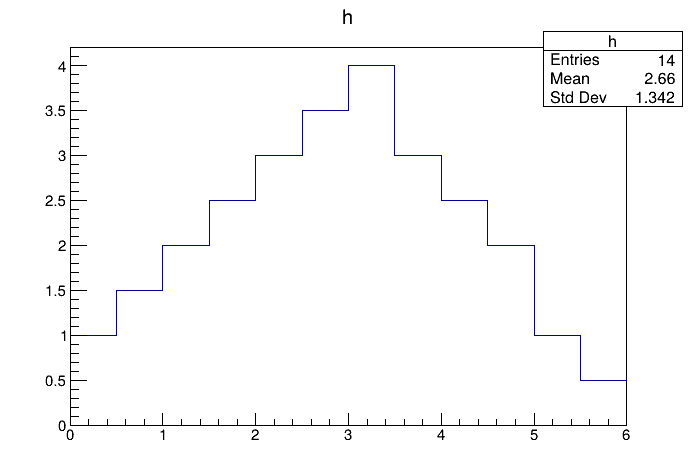

In [4]:
TH1D * h = new TH1D("h","h",12,0,6);
Double_t count[12]={1,1.5,2,2.5,3,3.5,4,3,2.5,2,1,0.5};
h->Fill(-2,1);//underflow
for(int i=0;i<12;i++) h->Fill(i/2.,count[i]);
h->Fill(15,2);//overflow
h->SetMinimum(0);
h->Draw("hist");
c1->Draw();


<h3 id="For-all-histogram-types:-nbins,-xlow,-xup">For all histogram types: nbins, xlow, xup</h3><div class="highlight"><pre><span></span><span class="n">bin</span> <span class="o">=</span> <span class="mi">0</span><span class="p">;</span> <span class="n">underflow</span> <span class="n">bin</span>
<span class="n">bin</span> <span class="o">=</span> <span class="mi">1</span><span class="p">;</span> <span class="n">first</span> <span class="n">bin</span> <span class="n">with</span> <span class="n">low</span><span class="o">-</span><span class="n">edge</span> <span class="n">xlow</span> <span class="n">INCLUDED</span>
<span class="n">bin</span> <span class="o">=</span> <span class="n">nbins</span><span class="p">;</span> <span class="n">last</span> <span class="n">bin</span> <span class="n">with</span> <span class="n">upper</span><span class="o">-</span><span class="n">edge</span> <span class="n">xup</span> <span class="n">EXCLUDED</span>
<span class="n">bin</span> <span class="o">=</span> <span class="n">nbins</span><span class="o">+</span><span class="mi">1</span><span class="p">;</span> <span class="n">overflow</span> <span class="n">bin</span>
</pre></div>


In [6]:
h->Print("all");

TH1.Print Name  = h, Entries= 14, Total sum= 26.5
 fSumw[0]=1, x=-0.25, error=1
 fSumw[1]=1, x=0.25, error=1
 fSumw[2]=1.5, x=0.75, error=1.5
 fSumw[3]=2, x=1.25, error=2
 fSumw[4]=2.5, x=1.75, error=2.5
 fSumw[5]=3, x=2.25, error=3
 fSumw[6]=3.5, x=2.75, error=3.5
 fSumw[7]=4, x=3.25, error=4
 fSumw[8]=3, x=3.75, error=3
 fSumw[9]=2.5, x=4.25, error=2.5
 fSumw[10]=2, x=4.75, error=2
 fSumw[11]=1, x=5.25, error=1
 fSumw[12]=0.5, x=5.75, error=0.5
 fSumw[13]=2, x=6.25, error=2


<h3 id="1.-Edge-and-content-of-a-bin-in-TH1">1. Edge and content of a bin in TH1</h3>


In [8]:
Double_t bin7cen=h->GetBinCenter(7);
Double_t bin7con=h->GetBinContent(7);
Double_t bin7low=h->GetBinLowEdge(7);
Double_t bin7width=h->GetBinWidth(7);
cout<<"GetBinCenter(7)="<<bin7cen<<"; GetBinContent(7)="<<bin7con<<endl;
cout<<"GetBinLowEdge(7)="<<bin7low<<"; GetBinWidth(7)="<<bin7width<<"; BinUpperEdge(7)="<<bin7low+bin7width<<endl;

GetBinCenter(7)=3.25; GetBinContent(7)=4
GetBinLowEdge(7)=3; GetBinWidth(7)=0.5; BinUpperEdge(7)=3.5


<h4 id="Create-TF1">Create TF1</h4>


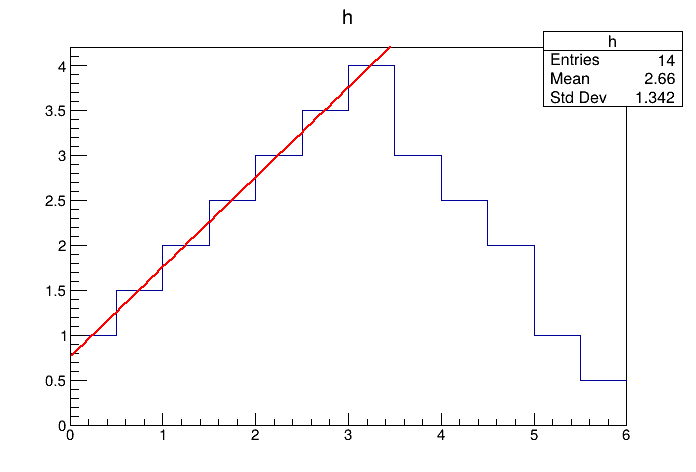

In [10]:
TF1 * f = new TF1("f","pol1",0,6);
f->SetParameters(0.75,1);
h->Draw("hist");
f->Draw("same");
c1->Draw();


<h3 id="2.-Integration-in-TH1-&amp;-TF1">2. Integration in TH1 &amp; TF1</h3><ol>
<li>bin(TH1)-&gt;x(TF1)</li>
</ol>
<p>TH1::Integral 累加 bin content；TF1::Integral 积分连续函数。只有当函数表示“每个等宽 bin 的期望计数”时，后者才除以 bin width 来换算计数。若函数本来是计数密度，直接积分；变宽 bin 应逐 bin 处理。此例只比较积分定义，不是从这些点拟合得到 f。</p>

In [12]:
int bin1=1;
int bin2=7;
Double_t sumH=h->Integral(bin1,bin2);

Double_t x1=h->GetBinLowEdge(bin1);
Double_t x2=h->GetBinLowEdge(bin2)+h->GetBinWidth(bin2);
Double_t sumF=f->Integral(x1,x2)/h->GetBinWidth(bin2);//!!!!!!!!!

cout<<"Integraion in TH1: "<<bin1<<"-"<<bin2<<"   "<<sumH<<endl;
cout<<"Integraion in TF1: "<<x1<<"-"<<x2<<" "<<sumF<<endl;

Integraion in TH1: 1-7   17.5
Integraion in TF1: 0-3.5 17.5


<ol>
<li>x(TF1)-&gt;bin(TH1)</li>
</ol>
<ul>
<li>x-&gt;Bin-&gt;fx</li>
</ul>
<p>这里把任意 x 区间扩展到完整 bin 的外边缘。FindBin 返回包含 x 的 bin；恰在边界时需先决定采用闭区间还是半开区间，不默认取部分 bin 计数。</p>

In [14]:
Double_t x1=0;
Double_t x2=3.4;
int bin1=h->FindBin(x1);
int bin2=h->FindBin(x2);
double fx1=h->GetBinLowEdge(bin1);
double fx2=h->GetBinLowEdge(bin2)+h->GetBinWidth(bin2);
Double_t sumF=f->Integral(fx1,fx2)/h->GetBinWidth(bin2);
Double_t sumH=h->Integral(bin1,bin2);
cout<<"Original xrange:   "<<x1<<"-"<<x2<<endl;
cout<<"Integraion in TF1: "<<fx1<<"-"<<fx2<<" "<<sumF<<endl;
cout<<"Integraion in TH1: "<<bin1<<"-"<<bin2<<"   "<<sumH<<endl;

Original xrange:   0-3.4
Integraion in TF1: 0-3.5 17.5
Integraion in TH1: 1-7   17.5